In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [1]:
import os
print(os.listdir("/content/drive"))

['Othercomputers', '.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


In [2]:
print(os.listdir("/content/drive/MyDrive/Final_Project"))

['zends_final_data.csv', 'intent_model_logs', 'intent_model', 'sentiment_model_logs', 'sentiment_model', 'ZENDS_Communications_.pdf']


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

INTENT_MODEL_PATH = "/content/drive/MyDrive/Final_Project/intent_model"
SENTIMENT_MODEL_PATH = "/content/drive/MyDrive/Final_Project/sentiment_model"

intent_tokenizer = AutoTokenizer.from_pretrained(INTENT_MODEL_PATH, local_files_only=True)
intent_model = AutoModelForSequenceClassification.from_pretrained(INTENT_MODEL_PATH, local_files_only=True)

sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_PATH, local_files_only=True)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL_PATH, local_files_only=True)

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Final_Project/zends_final_data.csv")
print(df.head())
print(df['intent'].value_counts())


                                              text     intent sentiment
0      The terrible experience with Postpaid Gold.  complaint     angry
1    Details about ZENDMeet and the 1TB FUP limit.    product   neutral
2     I am unhappy with my prepaid basic service .  complaint     angry
3  This is unacceptable. ZENDCloud VM Pro is slow.  complaint     angry
4       The ZENDStream service is down in the USA.  technical   neutral
intent
complaint    4000
product      4000
technical    4000
billing      4000
refund       4000
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['intent_label'] = label_encoder.fit_transform(df['intent'])

num_labels = len(label_encoder.classes_)
print("Intent Classes:", label_encoder.classes_)
print("Number of labels:", num_labels)


Intent Classes: ['billing' 'complaint' 'product' 'refund' 'technical']
Number of labels: 5


In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['intent_label'].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df['intent_label']
)

model_name = "distilbert-base-uncased" #Recommended Fine-tune HuggingFace Transformer model

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IntentDataset(train_encodings, train_labels)
val_dataset = IntentDataset(val_encodings, val_labels)

training_args = TrainingArguments(
    output_dir="./intent_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=200,
    save_steps=500,
    save_total_limit=2,
)


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

results = trainer.evaluate()
print(results)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
200,0.313521
400,0.008780
600,0.003649
800,0.005142
1000,0.003230
1200,0.003744
1400,0.000624
1600,0.001382
1800,0.004005
2000,0.005573


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!pip install transformers datasets torch scikit-learn -q

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer

data_path = "/content/drive/MyDrive/Final_Project/zends_final_data.csv"
df = pd.read_csv(data_path)

label_encoder = LabelEncoder()
df['intent_label'] = label_encoder.fit_transform(df['intent'])

num_labels = len(label_encoder.classes_)

print("Intent classes:", label_encoder.classes_)
print("Number of labels:", num_labels)

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['intent_label'].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df['intent_label']
)

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=64  # faster training
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IntentDataset(train_encodings, train_labels)
val_dataset = IntentDataset(val_encodings, val_labels)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/intent_model_logs",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=200,
    save_steps=1000,
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

save_path = "/content/drive/MyDrive/Final_Project/intent_model"

trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

import joblib
joblib.dump(label_encoder, f"{save_path}/label_encoder.pkl")

print("✅ Model saved successfully!")


Intent classes: ['billing' 'complaint' 'product' 'refund' 'technical']
Number of labels: 5


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.245175
400,0.007887
600,0.004382
800,0.002142
1000,0.003553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!


Sentiment classes: ['angry' 'happy' 'neutral']
Number of sentiment labels: 3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.153790
400,0.020346
600,0.008139
800,0.004979
1000,0.003241


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.007790279109030962, 'eval_accuracy': 0.998, 'eval_f1': 0.998, 'eval_precision': 0.998, 'eval_recall': 0.998, 'eval_runtime': 1.9209, 'eval_samples_per_second': 1041.186, 'eval_steps_per_second': 32.797, 'epoch': 2.0}


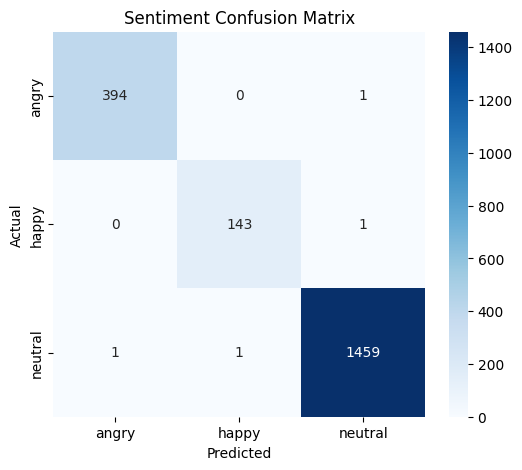

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       395
       happy       0.99      0.99      0.99       144
     neutral       1.00      1.00      1.00      1461

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Sentiment model saved successfully!


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data_path = "/content/drive/MyDrive/Final_Project/zends_final_data.csv"
df = pd.read_csv(data_path)

# Encode sentiment labels
sentiment_encoder = LabelEncoder()
df['sentiment_label'] = sentiment_encoder.fit_transform(df['sentiment'])

num_sentiment_labels = len(sentiment_encoder.classes_)

print("Sentiment classes:", sentiment_encoder.classes_)
print("Number of sentiment labels:", num_sentiment_labels)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['sentiment_label'].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df['sentiment_label']
)

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_sentiment_labels
)

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=64
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/sentiment_model_logs",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=200,
    save_steps=1000,
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

results = trainer.evaluate()
print(results)

predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(val_labels, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sentiment_encoder.classes_,
            yticklabels=sentiment_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()

print(classification_report(val_labels, y_pred, target_names=sentiment_encoder.classes_))

save_path = "/content/drive/MyDrive/Final_Project/sentiment_model"

trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

import joblib
joblib.dump(sentiment_encoder, f"{save_path}/sentiment_encoder.pkl")

print("✅ Sentiment model saved successfully!")


In [ ]:
train_results = trainer.evaluate(train_dataset)
print(train_results)

{'eval_loss': 0.0017767365789040923, 'eval_accuracy': 0.9997222222222222, 'eval_f1': 0.9997221963644548, 'eval_precision': 0.9997222661670433, 'eval_recall': 0.9997222222222222, 'eval_runtime': 18.9819, 'eval_samples_per_second': 948.271, 'eval_steps_per_second': 29.66, 'epoch': 2.0}


In [ ]:
#Step 4:

!pip install pypdf sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.6/330.6 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.0 MB/s eta 0:00:00


In [ ]:
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import joblib

# Paths (change if needed)
INTENT_MODEL_PATH = "/content/drive/MyDrive/Final_Project/intent_model"
SENTIMENT_MODEL_PATH = "/content/drive/MyDrive/Final_Project/sentiment_model"

# Load intent model
intent_tokenizer = AutoTokenizer.from_pretrained(INTENT_MODEL_PATH)
intent_model = AutoModelForSequenceClassification.from_pretrained(INTENT_MODEL_PATH)
intent_encoder = joblib.load(f"{INTENT_MODEL_PATH}/label_encoder.pkl")

# Load sentiment model
sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_PATH)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL_PATH)
sentiment_encoder = joblib.load(f"{SENTIMENT_MODEL_PATH}/sentiment_encoder.pkl")

print("✅ Intent & Sentiment models loaded successfully!")

def predict_intent_sentiment(text):
    # Intent prediction
    intent_inputs = intent_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    intent_outputs = intent_model(**intent_inputs)
    intent_pred = torch.argmax(intent_outputs.logits, dim=1).item()
    intent_label = intent_encoder.inverse_transform([intent_pred])[0]

    # Sentiment prediction
    sentiment_inputs = sentiment_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    sentiment_outputs = sentiment_model(**sentiment_inputs)
    sentiment_pred = torch.argmax(sentiment_outputs.logits, dim=1).item()
    sentiment_label = sentiment_encoder.inverse_transform([sentiment_pred])[0]

    return intent_label, sentiment_label

def get_priority(intent, sentiment):
    intent = intent.lower()
    sentiment = sentiment.lower()

    if sentiment == "negative" and intent in ["complaint", "technical"]:
        return "High"
    elif sentiment == "negative" and intent in ["billing", "refund"]:
        return "Medium"
    else:
        return "Low"

def copilot_predict(text):
    intent, sentiment = predict_intent_sentiment(text)
    priority = get_priority(intent, sentiment)

    return {
        "text": text,
        "intent": intent,
        "sentiment": sentiment,
        "priority": priority
    }

print(copilot_predict("My internet is not working and I'm very angry"))
print(copilot_predict("Tell me about your new broadband plan"))
print(copilot_predict("I want refund for my last bill"))

pdf_path = "/content/drive/My Drive/Final_Project/ZENDS_Communications_.pdf"

reader = PdfReader(pdf_path)
text = ""

for page in reader.pages:
    text += page.extract_text()

print(text[:1000])  # preview

def chunk_text(text, chunk_size=300):
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)

    return chunks

chunks = chunk_text(text)
print("Total chunks:", len(chunks))
print(chunks[0])

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(chunks, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

print("Vectors stored in FAISS:", index.ntotal)

def search_knowledge(query, top_k=3):
    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(np.array(query_embedding), top_k)

    results = [chunks[i] for i in indices[0]]
    return results

query = "What is refund policy for cloud services?"
results = search_knowledge(query)

for r in results:
    print("----")
    print(r)

def rag_copilot_response(user_query):

    result = copilot_predict(user_query)
    knowledge = search_knowledge(user_query, top_k=2)

    response = f"""
    🔹 Query: {user_query}
    🔹 Intent: {result['intent']}
    🔹 Sentiment: {result['sentiment']}
    🔹 Priority: {result['priority']}

    📚 Relevant ZENDS Knowledge:
    {knowledge[0]}
    """

    return response

print(rag_copilot_response("Can I get refund for cloud services?"))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Intent & Sentiment models loaded successfully!
{'text': "My internet is not working and I'm very angry", 'intent': 'complaint', 'sentiment': 'angry', 'priority': 'Low'}
{'text': 'Tell me about your new broadband plan', 'intent': 'product', 'sentiment': 'neutral', 'priority': 'Low'}
{'text': 'I want refund for my last bill', 'intent': 'refund', 'sentiment': 'neutral', 'priority': 'Low'}
ZENDS Communications
Powering Digital Life Everywhere
Company Overview
ZENDS Communications is a next-generation global telecom and digital services provider delivering mobile
connectivity,  broadband,  enterprise  networking,  cloud  infrastructure,  IoT,  cybersecurity,  and  digital
platforms. ZENDS serves both individual consumers and enterprise customers across multiple regions,
enabling personal communication, business operations, cloud computing, and smart-city services. ZENDS
operates across consumer telecom, enterprise telecom, cloud infrastructure, smart city and IoT, and digital
media and co

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (6, 384)
Vectors stored in FAISS: 6
----
services are non-refundable after activation. 3Contracts: Individual users have no long-term lock-in. Enterprise customers have a minimum 12-month contract. SLA: Individual users have 98.5% uptime, business users 99.5% uptime, and enterprise users 99.9% uptime. Data Privacy: GDPR compliant, ISO 27001 certified, and encrypted data at rest and in transit. Fair Usage: Unlimited plans are capped at 1TB per month. Support Tiers: Standard, Priority, and Enterprise Dedicated Support. Discounts: Bulk enterprise users can receive up to 30% discount. Annual payment discount is 15%. 4
----
in Singapore, and $224 in Thailand for enterprise customers. ZENDEnterprise Dedicated is priced at $500 in the USA, $300 in India, $550 in Singapore, and $400 in Thailand for individual users, and $450 in the USA, $270 in India, $495 in Singapore, and $360 in Thailand for enterprise customers. Services include dedicated bandwidth, MPLS connectivity, SLA-

In [ ]:
!pip install transformers accelerate

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/flan-t5-base"

tokenizer_llm = AutoTokenizer.from_pretrained(model_name)
model_llm = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_llm.to(device)

print("✅ FLAN-T5 model loaded!")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ FLAN-T5 model loaded!


In [ ]:
def build_prompt(user_query, intent, sentiment, knowledge):

    prompt = f"""
You are an AI customer support agent for a telecom company called ZENDS Communications.

Customer Query: {user_query}
Detected Intent: {intent}
Customer Sentiment: {sentiment}

Relevant Company Information:
{knowledge}

Task:
Generate a clear, polite, and professional response to the customer based on the company information.
Do not hallucinate. Use only the given information.
"""
    return prompt

def llm_generate(prompt, max_length=200):
    inputs = tokenizer_llm(prompt, return_tensors="pt", truncation=True).to(device)

    outputs = model_llm.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        temperature=0.3
    )

    return tokenizer_llm.decode(outputs[0], skip_special_tokens=True)

def generate_ai_response(user_query):

    # Step 1: Intent + Sentiment
    result = copilot_predict(user_query)

    # Step 2: Retrieve knowledge
    knowledge_chunks = search_knowledge(user_query, top_k=2)
    knowledge_text = "\n".join(knowledge_chunks)

    # Step 3: Build prompt
    prompt = build_prompt(user_query, result["intent"], result["sentiment"], knowledge_text)

    # Step 4: Generate response using LLM
    response_text = llm_generate(prompt)

    return {
        "query": user_query,
        "intent": result["intent"],
        "sentiment": result["sentiment"],
        "priority": result["priority"],
        "response": response_text
    }

print(generate_ai_response("What is the refund policy for broadband plans?"))
print(generate_ai_response("My internet is not working properly"))
print(generate_ai_response("Tell me about your 5G plans"))

{'query': 'What is the refund policy for broadband plans?', 'intent': 'refund', 'sentiment': 'neutral', 'priority': 'Low', 'response': 'Pakistan as one rate limit'}
{'query': 'My internet is not working properly', 'intent': 'technical', 'sentiment': 'neutral', 'priority': 'Low', 'response': 'at $1,000 $6.6equivelveae; $372.940=43.00 dollars ether in both mobile, and $153.64 was $749.00 outground as against $2889 outgalving customers iterperpente and $0.493.89 and $5299.95.89, depending upon data availability charges , but all available storage (adsga-, or media (odpop), respectively...acjfjbadf3gg@zondhisatansoftwareteam (zimenete@yahoollcq), who used Zivk&cdwhyw0gkrs3w_5xjh6 and its affiliate...anxous [electuro-czaves4-invividyorisoy-jawan+d-evipcoupling[i1|p&on1(l'}
{'query': 'Tell me about your 5G plans', 'intent': 'product', 'sentiment': 'neutral', 'priority': 'Low', 'response': 'ZivaNet'}
